In [1]:
from pathlib import Path
from src.db import get_connection
import sqlite3

import numpy as np
import pandas as pd

import torch

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")


DATABASE_PATH = Path.home() / "HDD/Datasets/annas_archive_spotify_2025_07/spotify_clean_playlists.sqlite3"

cuda available
gpu ready


In [2]:
conn  = get_connection(DATABASE_PATH)
print("Connected to database")

Connected to database


In [3]:
def fetch_topn_playlist_tracks(conn, n):
    """Fetch all valid (playlist_rowid, track_rowid) pairs for the top N playlists
    by followers. DISTINCT ensures each track appears at most once per playlist.
    """
    query = """
        SELECT DISTINCT pt.playlist_rowid, pt.track_rowid
        FROM playlist_tracks pt
        WHERE pt.playlist_rowid IN (
            SELECT rowid 
            FROM playlists 
            ORDER BY followers_total 
            DESC LIMIT ?
        )
          AND pt.is_episode = 0
          AND pt.is_local = 0
          AND pt.track_rowid IS NOT NULL
    """
    return pd.read_sql(query, conn, params=[n])

N = 131072
_playlist_tracks = fetch_topn_playlist_tracks(conn, N)
_playlist_tracks

,playlist_rowid,track_rowid
0,3,1
1,3,4
2,3,8
3,3,9
4,3,10
...,...,...
38486090,9882406,64252
38486091,9882406,64265
38486092,9882406,71789
38486093,9882406,64263


In [14]:
T_SUBSAMPLE = 1e-4


def subsample(pt: pd.DataFrame, t: float) -> pd.DataFrame:
    """Discard frequent track occurrences (word2vec subsampling).

    Track i is kept with probability min(1, sqrt(t / freq[i])).
    Applied before k-core so that subsampled tracks don't leave dead vocab entries.
    """
    freq = pt["track_rowid"].value_counts() / len(pt)
    keep_prob = np.minimum(1.0, np.sqrt(t / freq))
    p = pt["track_rowid"].map(keep_prob).values
    mask = np.random.rand(len(pt)) < p
    return pt[mask].reset_index(drop=True)


playlist_tracks = subsample(_playlist_tracks, T_SUBSAMPLE)
print(playlist_tracks)

          playlist_rowid  track_rowid
0                      3            1
1                      3            4
2                      3            8
3                      3            9
4                      3           10
...                  ...          ...
38485528         9882406        64252
38485529         9882406        64265
38485530         9882406        71789
38485531         9882406        64263
38485532         9882406       118885

[38485533 rows x 2 columns]


In [15]:
def filter_kcore(pt: pd.DataFrame, k: int, min_playlist_len: int=2) -> pd.DataFrame:
    """
    Iteratively remove tracks appearing in fewer than k playlists and playlists
    with fewer than min_playlist_len tracks, until the result is stable.

    A playlist with only one remaining track produces no center-context pairs
    and is useless for skip-gram training, hence min_playlist_len=2 by default.
    """
    while True:
        n_before = len(pt)

        track_counts = pt["track_rowid"].value_counts()
        pt = pt[pt["track_rowid"].map(track_counts) >= k]

        playlist_counts = pt["playlist_rowid"].value_counts()
        pt = pt[pt["playlist_rowid"].map(playlist_counts) >= min_playlist_len]

        if len(pt) == n_before:
            break
    return pt.reset_index(drop=True)

KCONN = 3
playlist_tracks = filter_kcore(playlist_tracks, k=KCONN)
print(f"Interactions     : {len(playlist_tracks):,}")
print(f"Unique tracks    : {playlist_tracks['track_rowid'].nunique():,}")
print(f"Playlists        : {playlist_tracks['playlist_rowid'].nunique():,}")
print(f"Min playlist len : {playlist_tracks["playlist_rowid"].value_counts().min()}")
print(f"Min track it.    : {playlist_tracks["track_rowid"].value_counts().min()}")

Interactions     : 32,361,679
Unique tracks    : 4,202,359
Playlists        : 258,681
Min playlist len : 2
Min track it.    : 2


In [16]:
def build_vocab(pt: pd.DataFrame) -> pd.DataFrame:
    """Build a track_rowid → track_id mapping from the filtered interaction table.

    Assigns a contiguous integer index to each unique track_rowid. The resulting
    DataFrame is indexed by track_rowid for fast join-based lookups.
    """
    unique_tracks = pt["track_rowid"].unique()
    return pd.DataFrame({
        "track_rowid": unique_tracks,
        "track_id": np.arange(len(unique_tracks)), 
    }).set_index("track_rowid")

vocab = build_vocab(playlist_tracks)
vocab

,track_id
track_rowid,
1,0
4,1
8,2
9,3
10,4
...,...
254162594,4202354
125582439,4202355
66644799,4202356


In [17]:
def map_vocab(pt: pd.DataFrame, vocab: pd.DataFrame) -> pd.DataFrame:
    """Replace track_rowid with the contiguous track_id from the vocab."""
    return pt.join(vocab, on="track_rowid").drop(columns=["track_rowid"])

playlist_tracks = map_vocab(playlist_tracks, vocab)
playlist_tracks

,playlist_rowid,track_id
0,3,0
1,3,1
2,3,2
3,3,3
4,3,4
...,...,...
32361674,9882406,170858
32361675,9882406,70109
32361676,9882406,70106
32361677,9882406,464778


In [18]:
def build_weights(pt: pd.DataFrame) -> torch.Tensor:
    """Build a normalised negative-sampling weight tensor aligned to track_id order.

    Weights are proportional to freq^0.75 (word2vec unigram smoothing): frequent
    tracks are sampled more often as negatives, but the exponent dampens the
    dominance of the very top tracks.

    The returned tensor has shape (vocab_size,) where position i is the sampling
    weight for track_id=i, ready for torch.multinomial.
    """
    freq = pt["track_id"].value_counts()
    weights = torch.tensor((freq ** 0.75).sort_index().to_numpy(), dtype=torch.float32)
    return weights / weights.sum()

weights = build_weights(playlist_tracks)
weights

tensor([5.8099e-06, 4.5487e-07, 3.7962e-06,  ..., 1.0570e-07, 1.0570e-07,
        1.0570e-07])

In [19]:
def flatten(pt: pd.DataFrame) -> dict[int, list[int]]:
    """Group interactions into a playlist → [track_ids] dictionary."""
    return pt.groupby("playlist_rowid")["track_id"].apply(list).to_dict()

# Model

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Word2Vec(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int):
        super().__init__()
        self.embeddings_in = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        self.embeddings_out = nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=embed_dim, sparse=True
        )
        nn.init.uniform_(self.embeddings_in.weight, -0.5 / embed_dim, 0.5 / embed_dim)
        nn.init.uniform_(self.embeddings_out.weight, -0.5 / embed_dim, 0.5 / embed_dim)

    def forward(
        self, center: torch.Tensor, context: torch.Tensor, negatives: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            pos_score: (batch,) dot product between center and context embeddings
            neg_score: (batch, K) dot products between center and each negative embedding
        """
        ecenter = self.embeddings_in(center)
        econtext = self.embeddings_out(context)
        enegative = self.embeddings_out(negatives)

        pos_score = (ecenter * econtext).sum(dim=1)
        neg_score = torch.bmm(enegative, ecenter.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score

    @property
    def track_embeddings(self) -> torch.Tensor:
        return self.embeddings_in.weight.detach()

# Loss

In [21]:
def skipgram_loss(
    pos_score: torch.Tensor, neg_score: torch.Tensor
) -> torch.Tensor:
    """Negative-sampling loss for skip-gram Word2Vec."""
    pos_loss = F.logsigmoid(pos_score)
    neg_loss = F.logsigmoid(-neg_score).sum(dim=1)
    return -(pos_loss + neg_loss).mean()

# Dataset

In [22]:
def playlist_pairs(playlist: list[int], W: int) -> tuple[torch.Tensor, torch.Tensor]:
    t = torch.tensor(playlist, dtype=torch.long)
    W = min(2 * W, len(playlist) - 1)
    offsets = [k for k in range(-W // 2, W // 2 + 1) if k]
    centers = t.repeat(len(offsets))
    contexts = torch.cat([torch.roll(t, -k) for k in offsets])
    return torch.stack((centers, contexts))



def pairs(playlist, W):
    c, x = playlist_pairs(playlist, W)
    return list(zip(c.tolist(), x.tolist()))


assert pairs([1,2,3], 1) == [(1,3),(2,1),(3,2),(1,2),(2,3),(3,1)]
assert pairs([1,2,3,4], 1) == [(1,4),(2,1),(3,2),(4,3),(1,2),(2,3),(3,4),(4,1)]
assert pairs([1,2,3,4,5], 2) == [(1,4),(2,5),(3,1),(4,2),(5,3),(1,5),(2,1),(3,2),(4,3),(5,4),(1,2),(2,3),(3,4),(4,5),(5,1),(1,3),(2,4),(3,5),(4,1),(5,2)]
assert pairs([1,2], 5) == [(1, 2), (2, 1)]
assert pairs([1,2,3,4], 100) == pairs([1,2,3,4], 2)

In [23]:
np.random.seed(0)

playlist_unique = playlist_tracks["playlist_rowid"].unique()
np.random.shuffle(playlist_unique)
playlist_train = playlist_unique[:int(0.9 * len(playlist_unique))]
train_mask = playlist_tracks["playlist_rowid"].isin(playlist_train)
train_df = playlist_tracks[train_mask].reset_index(drop=True)
valid_df = playlist_tracks[~train_mask].reset_index(drop=True)
print(f"train amounts to {100 * len(train_df) / len(playlist_tracks):.1f} % of the dataset")

train amounts to 89.9 % of the dataset


In [24]:
from typing import Callable

def get_nsampler(weights_gpu: torch.Tensor, K: int) -> Callable:
    return lambda n: torch.multinomial(weights_gpu, n * K, replacement=True).view(-1, K)


def precompute_pairs(playlists: pd.DataFrame, W: int) -> torch.Tensor:
    tensors = [playlist_pairs(p, W) for p in flatten(playlists).values() if len(p) >= 2]
    return torch.cat(tensors, dim=1)


W, K = 5, 15
train = precompute_pairs(train_df, W).pin_memory()
valid = precompute_pairs(valid_df, W).pin_memory()

# Training

In [ ]:
import time
from torch.optim import SparseAdam
from torch.optim.lr_scheduler import ReduceLROnPlateau

EMBED_DIM = 128
NEPOCHS = 25
LR = 1e-3
BATCH_SIZE = 32_000
SEED = 0
device = torch.device("cuda")

weights_gpu = weights.to(device)
neg_sample = get_nsampler(weights_gpu, K)
model = Word2Vec(vocab_size=len(vocab), embed_dim=EMBED_DIM)
model = model.to(device)
optimizer = SparseAdam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

history = {"train": [], "valid": [], "lr": []}
best_valid_loss = float("inf")
best_state = None
best_epoch = -1

for epoch in range(NEPOCHS):
    t0 = time.perf_counter()
    torch.manual_seed(SEED + epoch)
    perm = torch.randperm(train.shape[1])
    centers, contexts = train
    centers_s, contexts_s = centers[perm], contexts[perm]

    model.train()
    nt, tloss_epoch = 0, 0.
    for nt, offset in enumerate(range(0, len(centers_s), BATCH_SIZE)):
        c = centers_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
        x = contexts_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
        n = neg_sample(len(c))

        optimizer.zero_grad()
        loss = skipgram_loss(*model(c, x, n))
        loss.backward()
        optimizer.step()
        tloss_epoch += loss.item()

    t1 = time.perf_counter()
    perm = torch.randperm(valid.shape[1])
    centers, contexts = valid
    centers_s, contexts_s = centers[perm], contexts[perm]

    model.eval()
    nv, vloss_epoch = 0, 0.
    with torch.no_grad():
        for nv, offset in enumerate(range(0, len(centers_s), BATCH_SIZE)):
            c = centers_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
            x = contexts_s[offset:offset+BATCH_SIZE].to(device, non_blocking=True)
            n = neg_sample(len(c))
            vloss_epoch += skipgram_loss(*model(c, x, n)).item()

    t2 = time.perf_counter()

    train_loss = tloss_epoch / (nt + 1)
    valid_loss = vloss_epoch / (nv + 1)
    lr = optimizer.param_groups[0]["lr"]
    history["train"].append(train_loss)
    history["valid"].append(valid_loss)
    history["lr"].append(lr)

    is_best = valid_loss < best_valid_loss
    if is_best:
        best_valid_loss = valid_loss
        best_epoch = epoch + 1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    scheduler.step(valid_loss)

    w = len(str(NEPOCHS))
    print(
        f"epoch {epoch+1:{w}}/{NEPOCHS}"
        f"  │  train {train_loss:.4f}"
        f"  valid {valid_loss:.4f}"
        f"  │  lr {lr:.2e}"
        f"  │  {t2-t0:.0f}s  (train {t1-t0:.0f}s  valid {t2-t1:.0f}s)"
        + ("  *" if is_best else "")
    )

model.load_state_dict(best_state)
print(f"\nRestored best model from epoch {best_epoch}  (valid {best_valid_loss:.4f})")

### Recap

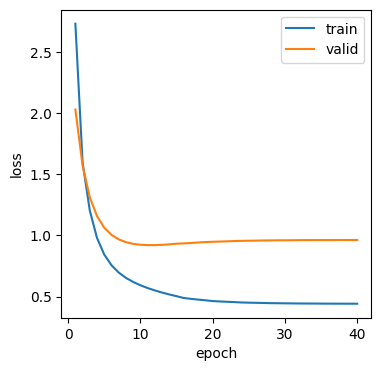

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))
epochs = range(1, len(history["train"]) + 1)
ax.plot(epochs, history["train"], label="train")
ax.plot(epochs, history["valid"], label="valid")
ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
plt.show()

# Qualitative checks

In [17]:
# Load track lookup, keep only columns we need, inner-join with vocab
lookup = pd.read_parquet(
    "../data/playlist/track_lookup.parquet",
    columns=["track_rowid", "track_name", "artist_name", "track_popularity"],
)
lookup = lookup.merge(vocab, on="track_rowid", how="inner")
print(f"{len(lookup):,} tracks in lookup (should match vocab size {len(vocab):,})")
lookup.head()

1,286,115 tracks in lookup (should match vocab size 1,286,115)


,track_rowid,track_name,artist_name,track_popularity,track_id
0,1,The Giver,Chappell Roan,89,0
1,4,Crash,NOTD,56,1
2,5,I Just Missed A Call,NOTD,51,29
3,7,WIFI,NOTD,55,46854
4,8,SMOKE THE PAIN AWAY,Calvin Harris,75,2


In [40]:
# L2-normalise embeddings once — cosine sim becomes a simple matmul
emb = model.track_embeddings.to(device)
emb_norm = emb / emb.norm(dim=1, keepdim=True)


def find_neighbours(query: str, k: int = 10, diverse: bool = True) -> pd.DataFrame:
    """Find top-k nearest neighbours by cosine similarity.

    `query` is matched case-insensitively against track_name. If multiple tracks
    match, the most popular one is used.
    If `diverse=True`, at most one track per artist is returned.
    """
    matches = lookup[lookup["track_name"].str.contains(query, case=False, na=False)]
    if matches.empty:
        print(f"No tracks matching '{query}'")
        return pd.DataFrame()

    row = matches.sort_values("track_popularity", ascending=False).iloc[0]
    tid = row["track_id"]
    print(f"Query: {row['track_name']} — {row['artist_name']}  (pop {row['track_popularity']})")

    sims = (emb_norm[tid] @ emb_norm.T).cpu().numpy()

    candidates = lookup.copy()
    candidates["similarity"] = sims[candidates["track_id"].values]
    candidates = candidates[candidates["track_id"] != tid]
    candidates = candidates.sort_values("similarity", ascending=False)
    if diverse:
        candidates = candidates.drop_duplicates(subset="artist_name")
    return candidates.head(k)[["track_name", "artist_name", "track_popularity", "similarity"]]

In [47]:
queries = [
    "Holland, 1945",
    "when you sleep",
    "Interzone",
    "About A Girl",
    "Battery",
    "Xtal",
    "Altibzz",
    "N.Y. State of Mind",
    "Mathematics",
    "Nuthin' But A 'G' Thang",
    "Figaro",
    "Bela Lugosi's Dead",
    "Just Like Heaven",
    "Once in a Lifetime",
    "Dunkelheit",
    "Valvonauta",
]

for q in queries:
    display(find_neighbours(q))
    print()

Query: Holland, 1945 — Neutral Milk Hotel  (pop 59)


,track_name,artist_name,track_popularity,similarity
779107,My Little Corner of the World,Yo La Tengo,16,0.964957
490869,King of Carrot Flowers Pt. 1,Neutral Milk Hotel,59,0.964947
9386,Planet Telex,Radiohead,62,0.964764
608047,Grave Architecture,Pavement,36,0.964251
45892,Obscured - Remastered,The Smashing Pumpkins,48,0.964205
490049,Mildred Pierce,Sonic Youth,47,0.962507
9232,You're so Great - 2012 Remaster,Blur,50,0.960429
32709,Heart Cooks Brain,Modest Mouse,52,0.959683
727982,Wave Of Mutilation - UK Surf,Pixies,52,0.959108
416186,Can't Cool Me Down,Car Seat Headrest,45,0.958875



Query: When You Sleep — my bloody valentine  (pop 62)


,track_name,artist_name,track_popularity,similarity
9002,Blow Out,Radiohead,64,0.948694
9288,Cupid De Locke - Remastered 2012,The Smashing Pumpkins,63,0.921752
416199,High to Death,Car Seat Headrest,54,0.919998
723482,Rain,bôa,0,0.919852
25611,Marigold,Nirvana,64,0.918162
756975,Off Your Face,my bloody valentine,44,0.916489
22969,Alison,Slowdive,64,0.916461
25712,Girl Singing in the Wreckage,Black Box Recorder,50,0.915143
718570,All I Think About Now,Pixies,0,0.914774
5487,You've Got Everything Now - David Jensen Sessi...,The Smiths,44,0.912993



Query: Interzone - 2007 Remaster — Joy Division  (pop 47)


...

,track_name,artist_name,track_popularity,similarity
85731,This Is the Day,The The,60,0.867008
680729,Whip It,DEVO,52,0.862457
24155,Making Plans For Nigel,XTC,58,0.848857
678277,Heaven,The Psychedelic Furs,47,0.847904
24153,Electricity - Remastered 2003,Orchestral Manoeuvres In The Dark,58,0.846966
5160,Love Action (I Believe In Love),The Human League,54,0.846856
680915,Girlfriend in a Coma - 2011 Remaster,The Smiths,59,0.842332
102566,Burning Down the House,Talking Heads,68,0.842149
23906,Train in Vain (Stand by Me) - Remastered,The Clash,63,0.840166
24075,Planet Earth - 2010 Remaster,Duran Duran,53,0.839492



Query: Dunkelheit — Burzum  (pop 54)


,track_name,artist_name,track_popularity,similarity
857590,Manifesto,Harakiri for the Sky,33,0.974880
857592,Þjáning Heillar Þjóðar,Auðn,20,0.973910
996683,The Distant Dream of Life,Shape Of Despair,0,0.972883
657245,"Disgusting Semla (""December Moon"" Demo 1986)",Morbid,31,0.972346
796911,Summoning Lupine,Leviathan,24,0.971522
52640,Battles in the North,Immortal,36,0.970537
799778,Jeg faller,Burzum,34,0.970405
648440,Blood Fire Death,Bathory,37,0.969945
667442,Pagan Fears,Mayhem,43,0.969489
856157,Gorgoroth,Gorgoroth,28,0.969075



Query: Valvonauta — Verdena  (pop 43)


,track_name,artist_name,track_popularity,similarity
627026,Luna,Verdena,43,0.902619
663416,Fata Morgana,Litfiba,43,0.901393
139037,Altrove,Morgan,43,0.901079
331899,Sole Spento,Timoria,42,0.896981
284856,Quello Che Non C'è,Afterhours,41,0.895472
285837,Io non mi sento italiano,Giorgio Gaber,44,0.887131
139289,Quello che non ho,Fabrizio De André,42,0.886601
1203122,29 Settembre,Equipe 84,32,0.885520
139557,Mi manchi,Fausto Leali,39,0.884082
138835,Gli Spari Sopra (Celebrate),Vasco Rossi,49,0.882503


## Curated genre UMAP

In [33]:
# Parse genre_artists.txt → {genre: [artist_name]}
genre_artists = {}
current_genre = None
with open("genre_artists.txt") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith("#"):
            current_genre = line[1:].strip()
            genre_artists[current_genre] = []
        else:
            genre_artists[current_genre].append(line)

for g, artists in genre_artists.items():
    print(f"{g}: {len(artists)} artists")

new-wave: 14 artists
post-punk: 14 artists
70s-punk: 13 artists
grunge: 13 artists
thrash-metal: 13 artists
black-metal: 13 artists
dark-wave: 13 artists
90s-west-coast-hip-hop: 13 artists
90s-east-coast-hip-hop: 13 artists
conscious-hip-hop: 13 artists
IDM: 13 artists


In [34]:
# Join curated artists with lookup to get their tracks + track_ids
rows = []
for genre, artists in genre_artists.items():
    for artist in artists:
        mask = lookup["artist_name"].str.lower() == artist.lower()
        matched = lookup[mask]
        for _, row in matched.iterrows():
            rows.append({
                "genre": genre,
                "artist_name": row["artist_name"],
                "track_name": row["track_name"],
                "track_id": row["track_id"],
            })

genre_df = pd.DataFrame(rows)
print(f"{len(genre_df):,} tracks matched across {genre_df['genre'].nunique()} genres")
print(f"{genre_df['artist_name'].str.lower().nunique()} unique artists matched")
print()
print(genre_df["genre"].value_counts().to_string())

10,611 tracks matched across 11 genres
139 unique artists matched

genre
90s-west-coast-hip-hop    1677
90s-east-coast-hip-hop    1665
new-wave                  1472
thrash-metal              1332
grunge                    1051
post-punk                  968
conscious-hip-hop          885
70s-punk                   546
IDM                        539
dark-wave                  330
black-metal                146


In [35]:
import umap

# Extract embeddings for the curated tracks
track_ids = genre_df["track_id"].values
genre_emb = emb_norm[track_ids].cpu().numpy()

reducer = umap.UMAP(n_components=2, metric="cosine")
coords = reducer.fit_transform(genre_emb)
genre_df["umap_x"] = coords[:, 0]
genre_df["umap_y"] = coords[:, 1]
print(f"UMAP done — {len(coords)} points")

UMAP done — 10611 points


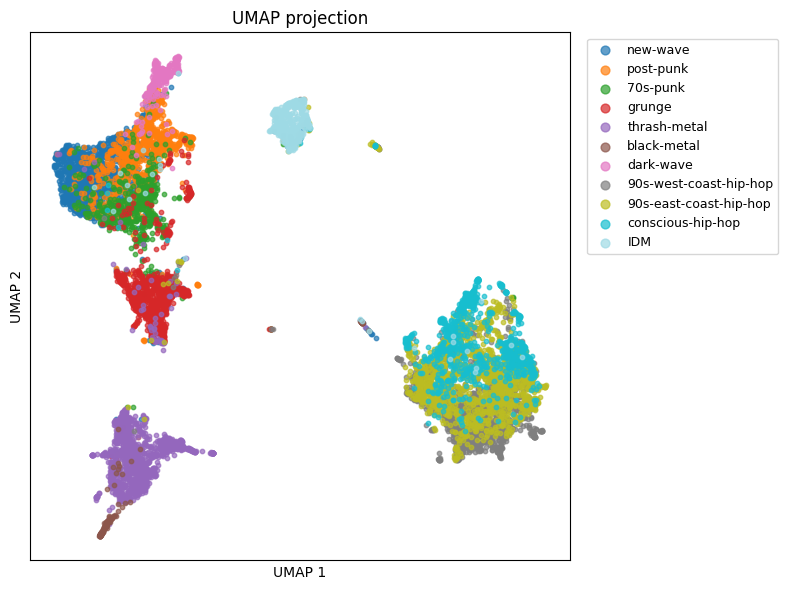

In [39]:
import matplotlib

fig, ax = plt.subplots(figsize=(8, 6))

genres = genre_df["genre"].unique()
cmap = plt.colormaps["tab20"].resampled(len(genres))

for i, genre in enumerate(genres):
    subset = genre_df[genre_df["genre"] == genre]
    ax.scatter(
        subset["umap_x"], subset["umap_y"],
        c=[cmap(i)], label=genre, s=10, alpha=0.7,
    )

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9, markerscale=2)
ax.set_title("UMAP projection")
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()